# SAR Automatic Target Recognition — Full Pipeline

**Environment**: Vast.ai GPU instance  
**Dataset**: MSTAR (10 vehicle classes, ~1000 SAR images)  
**Model**: CNN + GNN few-shot open-set recognition  

Run cells top-to-bottom. Each section is self-contained and can be re-run independently.

---

## 0. GPU Check

In [9]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else 'No GPU detected — check instance type')

Sat Apr 18 17:50:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        On  |   00000000:C1:00.0 Off |                  N/A |
|  0%   41C    P8              6W /  575W |       4MiB /  32607MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [10]:
import torch
print('PyTorch version :', torch.__version__)
print('CUDA available  :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU             :', torch.cuda.get_device_name(0))
    print('VRAM            :', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')

PyTorch version : 2.11.0+cu130
CUDA available  : True
GPU             : NVIDIA GeForce RTX 5090
VRAM            : 33.7 GB


## 1. Environment Setup

**Why `sys.executable` instead of `!pip`?**  
On Vast.ai, the Jupyter kernel runs inside a specific Python environment (e.g. a conda env or virtualenv). The bare `!pip` command calls whatever `pip` is first on the system `PATH` — which is often a *different* Python than the kernel. Packages installed there are invisible to the kernel, causing `ModuleNotFoundError` even after a successful install. Using `sys.executable -m pip` guarantees the install goes into the exact Python that is running this notebook.

In [11]:
import sys

# Show exactly which Python the kernel is using
print('Kernel Python   :', sys.executable)
print('Python version  :', sys.version)
print()
print('This is the Python that pip must install into.')
print('The next cell uses sys.executable to guarantee that.')

Kernel Python   : /venv/main/bin/python
Python version  : 3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 16:50:00) [GCC 14.3.0]

This is the Python that pip must install into.
The next cell uses sys.executable to guarantee that.


In [12]:
import sys

# Install all packages into the kernel's own Python — never fails due to PATH mismatch
packages = [
    'gdown',
    'scikit-learn',
    'scikit-image',
    'matplotlib',
    'Pillow',
    'numpy',
]

print(f'Installing into: {sys.executable}\n')
!{sys.executable} -m pip install -q {' '.join(packages)}
print('\nInstallation complete.')

Installing into: /venv/main/bin/python


Installation complete.


In [13]:
import sys

# Uncomment if torch / torchvision are missing on this instance
# (Vast.ai PyTorch templates have them pre-installed — check the GPU Check cell above)

# !{sys.executable} -m pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu118

In [14]:
# Verify every package the project needs is importable in THIS kernel
import importlib, sys

required = {
    'torch'       : 'torch',
    'torchvision' : 'torchvision',
    'numpy'       : 'numpy',
    'PIL'         : 'Pillow',
    'sklearn'     : 'scikit-learn',
    'skimage'     : 'scikit-image',
    'matplotlib'  : 'matplotlib',
    'gdown'       : 'gdown',
}

all_ok = True
for mod, pkg in required.items():
    try:
        m = importlib.import_module(mod)
        ver = getattr(m, '__version__', 'n/a')
        print(f'  OK  {pkg:<16} ({ver})')
    except ImportError:
        print(f'  MISSING  {pkg}  <-- run the install cell again')
        all_ok = False

print()
if all_ok:
    print('All packages verified — ready to continue.')
else:
    print('Fix missing packages before proceeding.')
    print('If the install cell ran but packages still show MISSING, restart the kernel')
    print('and run ONLY the install cell again before this one.')

  OK  torch            (2.11.0+cu130)
  OK  torchvision      (0.26.0+cu130)
  OK  numpy            (2.4.3)
  OK  Pillow           (12.1.1)
  OK  scikit-learn     (1.8.0)
  OK  scikit-image     (0.26.0)
  OK  matplotlib       (3.10.8)
  OK  gdown            (6.0.0)

All packages verified — ready to continue.


## 2. Clone / Upload Project Code

Choose **one** of the two options below depending on how your code is stored.

In [15]:
# Verify dataset structure
import os

DATASET_DIR = os.path.join(os.getcwd(), 'MSTAR')

if not os.path.exists(DATASET_DIR):
    raise FileNotFoundError(f'Dataset not found at {DATASET_DIR} — run the download cell first')

classes = sorted(os.listdir(DATASET_DIR))
print(f'Found {len(classes)} classes:\n')
total = 0
for cls in classes:
    cls_path = os.path.join(DATASET_DIR, cls)
    if not os.path.isdir(cls_path):
        continue
    n = len(os.listdir(cls_path))
    total += n
    marker = '  [UNSEEN - held out]' if cls == 'T72' else ''
    print(f'  {cls:<15} {n:>4} images{marker}')

print(f'\nTotal images : {total}')
assert 'T72' in classes, 'T72 class not found — check dataset structure'
print('\nDataset structure OK')

Found 10 classes:

  2S1              573 images
  BMP2             428 images
  BRDM_2           572 images
  BTR60            451 images
  BTR70            429 images
  D7               573 images
  T62              571 images
  T72              428 images  [UNSEEN - held out]
  ZIL131           573 images
  ZSU_23_4         573 images

Total images : 5171

Dataset structure OK


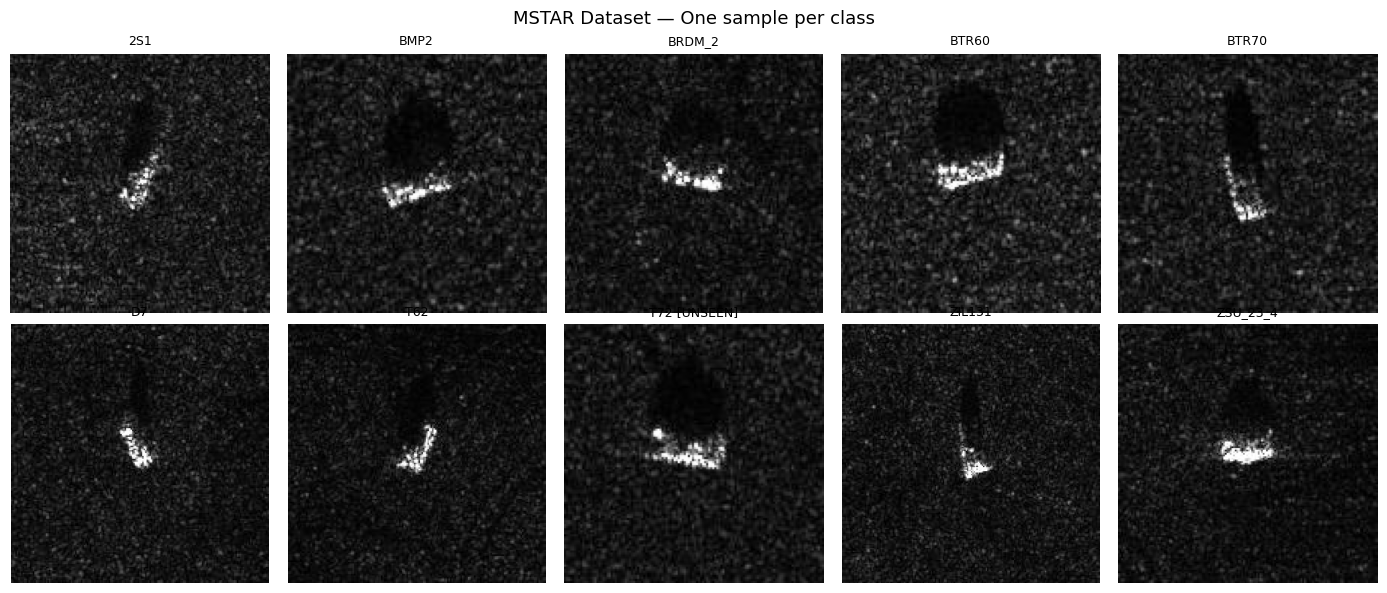

In [16]:
# Preview one image per class
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os, random

DATASET_DIR = os.path.join(os.getcwd(), 'MSTAR')
classes = sorted([c for c in os.listdir(DATASET_DIR)
                  if os.path.isdir(os.path.join(DATASET_DIR, c))])

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('MSTAR Dataset — One sample per class', fontsize=13)

for ax, cls in zip(axes.flat, classes):
    cls_dir = os.path.join(DATASET_DIR, cls)
    img_file = random.choice(os.listdir(cls_dir))
    img = mpimg.imread(os.path.join(cls_dir, img_file))
    ax.imshow(img, cmap='gray')
    ax.set_title(cls + (' [UNSEEN]' if cls == 'T72' else ''), fontsize=9)
    ax.axis('off')

plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/dataset_preview.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Create Output Directories

In [17]:
import os
for d in ['model', 'log', 'results', 'gan_output', 'model/gan']:
    os.makedirs(d, exist_ok=True)
print('Output directories ready')

Output directories ready


## 5. Shape Smoke Test

Verifies CNN and GNN produce the correct tensor shapes before committing to a long training run.

In [18]:
import sys, os
# Ensure project root is on the path (safe to call multiple times)
PROJECT_DIR = os.getcwd()
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

import torch
from cnn import EmbeddingCNN
from gnn import GNN_module

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Running smoke test on: {device}\n')

# CNN: (batch=4, channels=1, H=100, W=100) -> (batch, 64)
cnn = EmbeddingCNN(image_size=100, cnn_feature_size=64,
                   cnn_hidden_dim=32, cnn_num_layers=4).to(device)
x   = torch.rand(4, 1, 100, 100, device=device)
out = cnn(x)
assert out.shape == (4, 64), f'CNN shape error: {out.shape}'
print(f'CNN output shape  : {list(out.shape)}  OK')

# GNN: 3-way 20-shot, batch=8
nway, shots, batch = 3, 20, 8
D     = 64 + nway + 1       # CNN embed + one-hot label
N     = nway * shots + 1    # support nodes + 1 query
nodes = torch.rand(batch, N, D, device=device)
gnn   = GNN_module(nway=nway, input_dim=D, hidden_dim=16).to(device)
logits = gnn(nodes)
assert logits.shape == (batch, nway + 1), f'GNN shape error: {logits.shape}'
print(f'GNN output shape  : {list(logits.shape)}  OK  (batch x C+1 logits)')

# DataLoader
from data import self_DataLoader
dl         = self_DataLoader(root='MSTAR', nway=3,
                             unseen_class='T72', unseen_ratio=1.0)
batch_data = dl.load_tr_batch(batch_size=4, nway=3, num_shots=5)
print(f'DataLoader batch  : {[list(b.shape) for b in batch_data[:4]]}  OK')

print('\nAll smoke tests PASSED — safe to train')

Running smoke test on: cuda

CNN output shape  : [4, 64]  OK
GNN output shape  : [8, 4]  OK  (batch x C+1 logits)
unseen class: T72 (idx 7)
full_train_num: 3790
full_test_num:  953
few_data_num:   428
DataLoader batch  : [[4, 1, 100, 100], [4], [4, 4], [4]]  OK

All smoke tests PASSED — safe to train


---
## 6. Experiment 1 — Paper Baseline: FSL + GNN (3-way 20-shot)

Reproduces the reference paper configuration.  
**Target**: seen ≥ 95%, unseen ≥ 62%, overall ≥ 85%  
**Expected runtime**: ~40 min on a single GPU

In [19]:
import sys
!{sys.executable} main.py \
    --data_root     MSTAR \
    --model_type    gnn \
    --nway          3 \
    --shots         20 \
    --unseen_class  T72 \
    --unseen_ratio  1.0 \
    --batch_size    8 \
    --lr            0.001 \
    --max_iteration 100000 \
    --log_interval  100 \
    --eval_interval 500 \
    --early_stop    10 \
    --eval_output   results \
    --save \
    --use_gpu       0

todo             : train
dataset          : MSTAR
model_type       : gnn
use_gpu          : 0
seed             : 1
batch_size       : 8
lr               : 0.001
max_iteration    : 100000
log_interval     : 100
eval_interval    : 500
early_stop       : 10
early_stop_pretrain : 10
test_dir         : 
data_root        : MSTAR
log_root         : log
model_root       : model
affix            : 
save             : True
load             : False
load_dir         : model/3way_20shot_gnn_
output_dir       : output
output_name      : output.txt
nway             : 3
shots            : 20
freeze_cnn       : False
unseen_class     : T72
unseen_ratio     : 1.0
warmup_iters     : 2000
gan_augment      : False
gan_output_dir   : gan_output
physics_lambda   : 0.0
augment_rotation : False
augment_speckle  : False
speckle_sigma    : 0.1
eval_only        : False
eval_output      : results
baseline_kshot   : False
model_folder     : model/3way_20shot_gnn_
log_folder       : log/3way_20shot_gnn_
unseen class

In [38]:
# Show last 30 lines of the training log
import glob
log_files = sorted(glob.glob('log/3way_20shot_gnn_/*_log.txt'))
if log_files:
    with open(log_files[0]) as f:
        lines = f.readlines()
    print(''.join(lines[-30:]))
else:
    print('Log file not found — check log/ directory')

eval_interval    : 500
early_stop       : 10
early_stop_pretrain : 10
test_dir         : 
data_root        : mstar_sampled_data
log_root         : log
model_root       : model
affix            : 
save             : False
load             : True
load_dir         : model/3way_20shot_gnn_
output_dir       : output
output_name      : output.txt
nway             : 3
shots            : 20
freeze_cnn       : False
unseen_class     : T72
unseen_ratio     : 1.0
warmup_iters     : 2000
gan_augment      : False
gan_output_dir   : gan_output
physics_lambda   : 0.0
augment_rotation : False
augment_speckle  : False
speckle_sigma    : 0.1
eval_only        : True
eval_output      : results
baseline_kshot   : False
model_folder     : model/3way_20shot_gnn_
log_folder       : log/3way_20shot_gnn_

